# Telco Customer Churn — Exploratory Data Analysis

This notebook explores the IBM Telco Customer Churn dataset before modelling.  
We cover data types, distributions, missing values, and relationships with the churn target.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
DATA = Path('..') / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA)
print('Shape:', df.shape)

Shape: (7043, 21)


## 1. Schema Overview

In [21]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Observation — Mistyped Columns

`TotalCharges` is stored as **object** (string) even though it represents a monetary amount.  
Inspection reveals 11 rows where `TotalCharges` is a blank string `' '` — these correspond to  
customers with `tenure == 0` (brand-new customers who haven't yet been billed).  
We convert with `pd.to_numeric(errors='coerce')`, which maps the blanks to `NaN`, and  
handle them downstream via `SimpleImputer(strategy='median')`.

In [23]:
# Demonstrate the issue
print('dtype of TotalCharges:', df['TotalCharges'].dtype)
blank_mask = df['TotalCharges'].str.strip() == ''
print('Rows with blank TotalCharges:', blank_mask.sum())
df.loc[blank_mask, ['customerID', 'tenure', 'TotalCharges']].head()

dtype of TotalCharges: object
Rows with blank TotalCharges: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,
753,3115-CZMZD,0,
936,5709-LVOEQ,0,
1082,4367-NUYAO,0,
1340,1371-DWPAZ,0,


## 2. Target Distribution

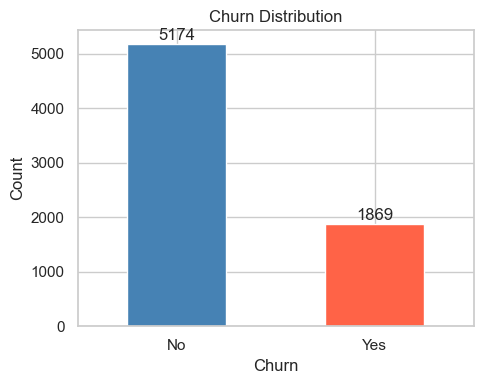

Churn rate: 26.54%


In [24]:
churn_counts = df['Churn'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()
print(f'Churn rate: {churn_counts["Yes"] / len(df):.2%}')

## 3. Numeric Column Distributions

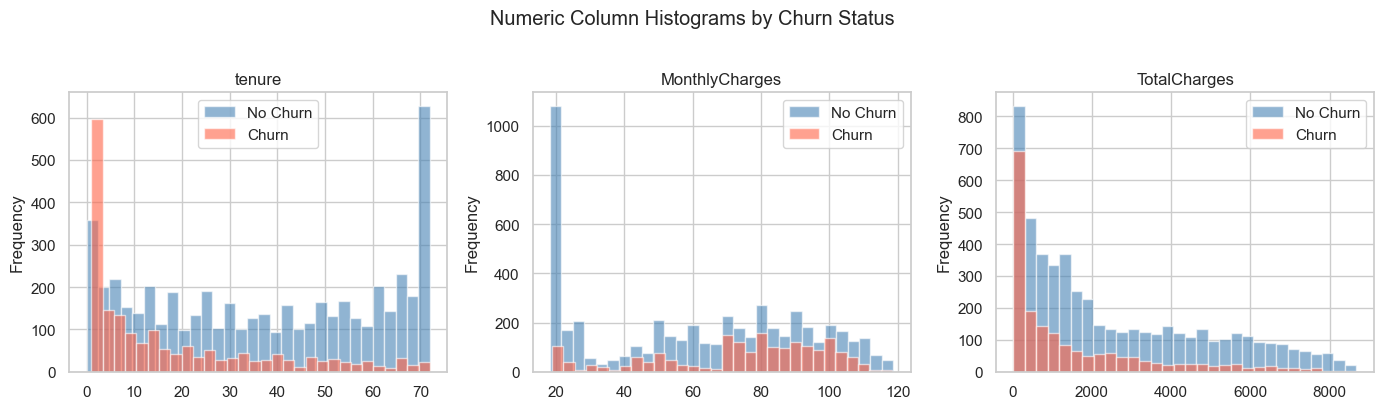

In [25]:
df2 = df.copy()
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    df2[df2['Churn'] == 'No'][col].dropna().plot(kind='hist', ax=ax, alpha=0.6,
                                                  bins=30, label='No Churn', color='steelblue')
    df2[df2['Churn'] == 'Yes'][col].dropna().plot(kind='hist', ax=ax, alpha=0.6,
                                                   bins=30, label='Churn', color='tomato')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Numeric Column Histograms by Churn Status', y=1.02)
plt.tight_layout()
plt.show()

## 4. Missing Value Analysis

In [26]:
missing = df2.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)
print('\nNote: TotalCharges NaN rows have tenure == 0 (new customers, not yet billed)')
print(df2[df2['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'Churn']].head(12))

Columns with missing values:
TotalCharges    11
dtype: int64

Note: TotalCharges NaN rows have tenure == 0 (new customers, not yet billed)
      tenure  MonthlyCharges Churn
488        0           52.55    No
753        0           20.25    No
936        0           80.85    No
1082       0           25.75    No
1340       0           56.05    No
3331       0           19.85    No
3826       0           25.35    No
4380       0           20.00    No
5218       0           19.70    No
6670       0           73.35    No
6754       0           61.90    No


## 5. Cross-tabulations with Churn

In [27]:
for col in ['Contract', 'PaymentMethod', 'InternetService']:
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    print(f'\n--- Churn rate by {col} (%) ---')
    print(ct[['Yes']].rename(columns={'Yes': 'Churn %'}).round(1).to_string())


--- Churn rate by Contract (%) ---
Churn           Churn %
Contract               
Month-to-month     42.7
One year           11.3
Two year            2.8

--- Churn rate by PaymentMethod (%) ---
Churn                      Churn %
PaymentMethod                     
Bank transfer (automatic)     16.7
Credit card (automatic)       15.2
Electronic check              45.3
Mailed check                  19.1

--- Churn rate by InternetService (%) ---
Churn            Churn %
InternetService         
DSL                 19.0
Fiber optic         41.9
No                   7.4


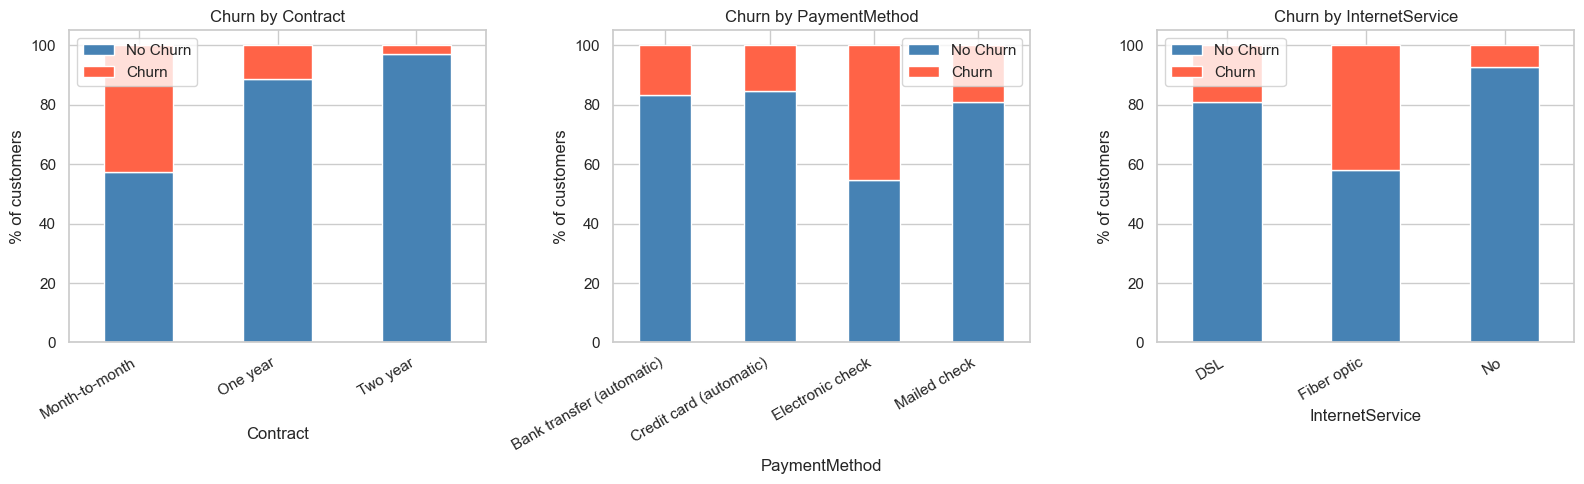

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Contract', 'PaymentMethod', 'InternetService']):
    ct = pd.crosstab(df[col], df['Churn'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
    ax.set_title(f'Churn by {col}')
    ax.set_ylabel('% of customers')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

## 6. Key Insights

1. **Class imbalance**: ~26.5% of customers churned vs 73.5% who did not.  
   A naive classifier that always predicts "No Churn" gets 73.5% accuracy but zero business value.  
   We optimise for **recall** (catching actual churners) subject to a precision floor.

2. **Contract type is the strongest predictor**: Month-to-month customers churn at ~43%,  
   while two-year contract customers churn at only ~3%.

3. **Fiber optic users have surprisingly high churn** (~42%) compared to DSL (~19%) or no internet (~7%).  
   This may reflect pricing dissatisfaction or competitive offers.

4. **Electronic check users churn at ~45%** — the highest of all payment methods.  
   Automatic payment methods correlate with retention.

5. **Tenure**: Short-tenure customers churn far more.  
   The `tenure_bucket` feature captures this non-linear relationship.

6. **TotalCharges** has 11 missing values (blank strings for `tenure == 0` customers).  
   These are handled by coercion to NaN followed by median imputation in the pipeline.